In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


Running on PyMC3 v3.11.5
Running on PyMC3 v3.11.5


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_bt_dem.csv").dropna()
participantcode = data.participant.unique()
data["confidence_BT"] = data["confidence_BT"]*0.1
data["confidence_BT"] = data["confidence_BT"].astype(theano.config.floatX)

In [4]:
fig = px.violin(data, y='confidence_BT',x="coherence", color='session',
                   orientation='v',
                violinmode='overlay',
                   labels={'confidence_BT': 'confidence_BT',
                            'acc': 'Response'},
                   width=1733,
                   height=900)

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Unnamed: 0', 'participant', 'index', 'session', 'draws', 'acc', 'confidence_BT', 'gender', 'age', 'pdi', 'caps', 'pdi_group', 'caps_group'] but received: coherence

In [5]:
fig = px.histogram(data, x="confidence_BT",
                   histnorm='probability density',
                   orientation='v',
                   labels={'draws': 'conf',
                            'acc': 'Response'},
                   barmode='overlay',
                   width=1733,
                   height=900)

fig.show()

In [5]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

median_conf=data["confidence_BT"].median()
hr_conf= pm.Model(coords=coords) 

with hr_conf:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0, sigma=100,testval=0.0)
    sigma_a = pm.HalfNormal("sigma_a", 5,testval=1)
    mu_beta_tms = pm.Normal("mu_beta_tms", mu=0, sigma=100)
    sigma_b_tms = pm.HalfNormal("sigma_b_tms", 5)
    mu_beta_caps = pm.Normal("mu_beta_caps", mu=0, sigma=100)
    sigma_b_caps = pm.HalfNormal("sigma_b_caps", 5)
    mu_beta_tmsXcaps = pm.Normal("mu_beta_tmsXcaps", mu=0, sigma=100)
    sigma_b_tmsXcaps = pm.HalfNormal("sigma_b_tmsXcaps", 5)


    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect tms  
    b = pm.Normal("b", mu=mu_beta_tms, sigma=sigma_b_tms, dims="participant")
    # effect coherence
    b_caps = pm.Normal("b_caps", mu=mu_beta_caps, sigma=sigma_b_caps, dims="participant")
    # effect interaction 
    b_tmsXcaps = pm.Normal("b_tmsXcaps", mu=mu_beta_tmsXcaps, sigma=sigma_b_tmsXcaps, dims="participant")


    # Model spec
    eps = pm.HalfCauchy("eps", 5)
    confidence_BT_est = (a[participant_idx] 
                      + b[participant_idx] * data.session.values
                      +b_caps[participant_idx] * data.caps.values
                      +b_tmsXcaps[participant_idx] * data.caps.values * data.session.values)

    # Data likelihood
    confidence_BT_like = pm.Normal(
        "confidence_BT_like", mu=confidence_BT_est, sigma=eps, observed=data.confidence_BT, dims="obs_id",testval=median_conf)
    
    

In [11]:
with hr_conf:
    hr_conf_trace = pm.sample(7000,tune=7000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b_tmsXcaps, b_caps, b, a, sigma_b_tmsXcaps, mu_beta_tmsXcaps, sigma_b_caps, mu_beta_caps, sigma_b_tms, mu_beta_tms, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 7_000 tune and 7_000 draw iterations (28_000 + 28_000 draws total) took 687 seconds.


0, dim: obs_id, 1357 =? 1357


There were 442 divergences after tuning. Increase `target_accept` or reparameterize.
There were 141 divergences after tuning. Increase `target_accept` or reparameterize.
There were 960 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.8191702071155612, but should be close to 0.9. Try to increase the number of tuning steps.
There were 261 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.


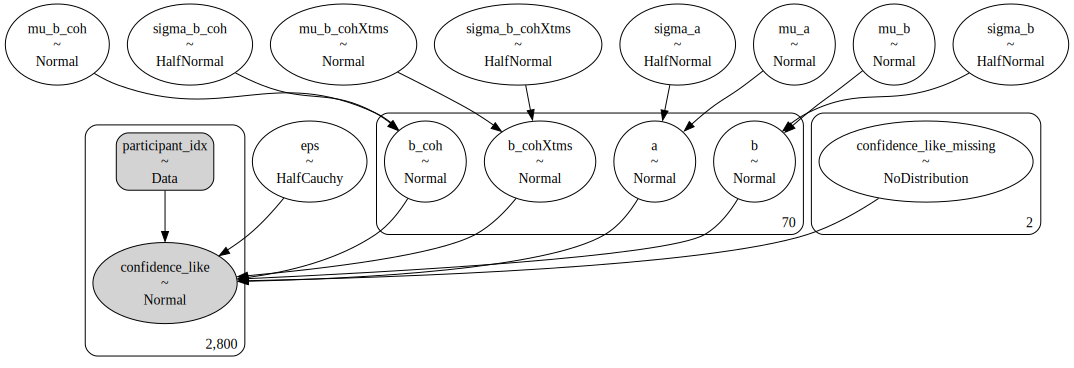

In [4]:
pm.model_to_graphviz(hr_conf)

In [13]:
# Save the model
with open('hr_conf_BTtmsxcaps.pkl', 'wb') as file:
    pickle.dump(hr_conf, file)
    
hr_conf_trace.to_netcdf('hr_conf_BTtmsXcaps_traces.nc', compress=False)    

'hr_conf_BTtmsXcaps_traces.nc'

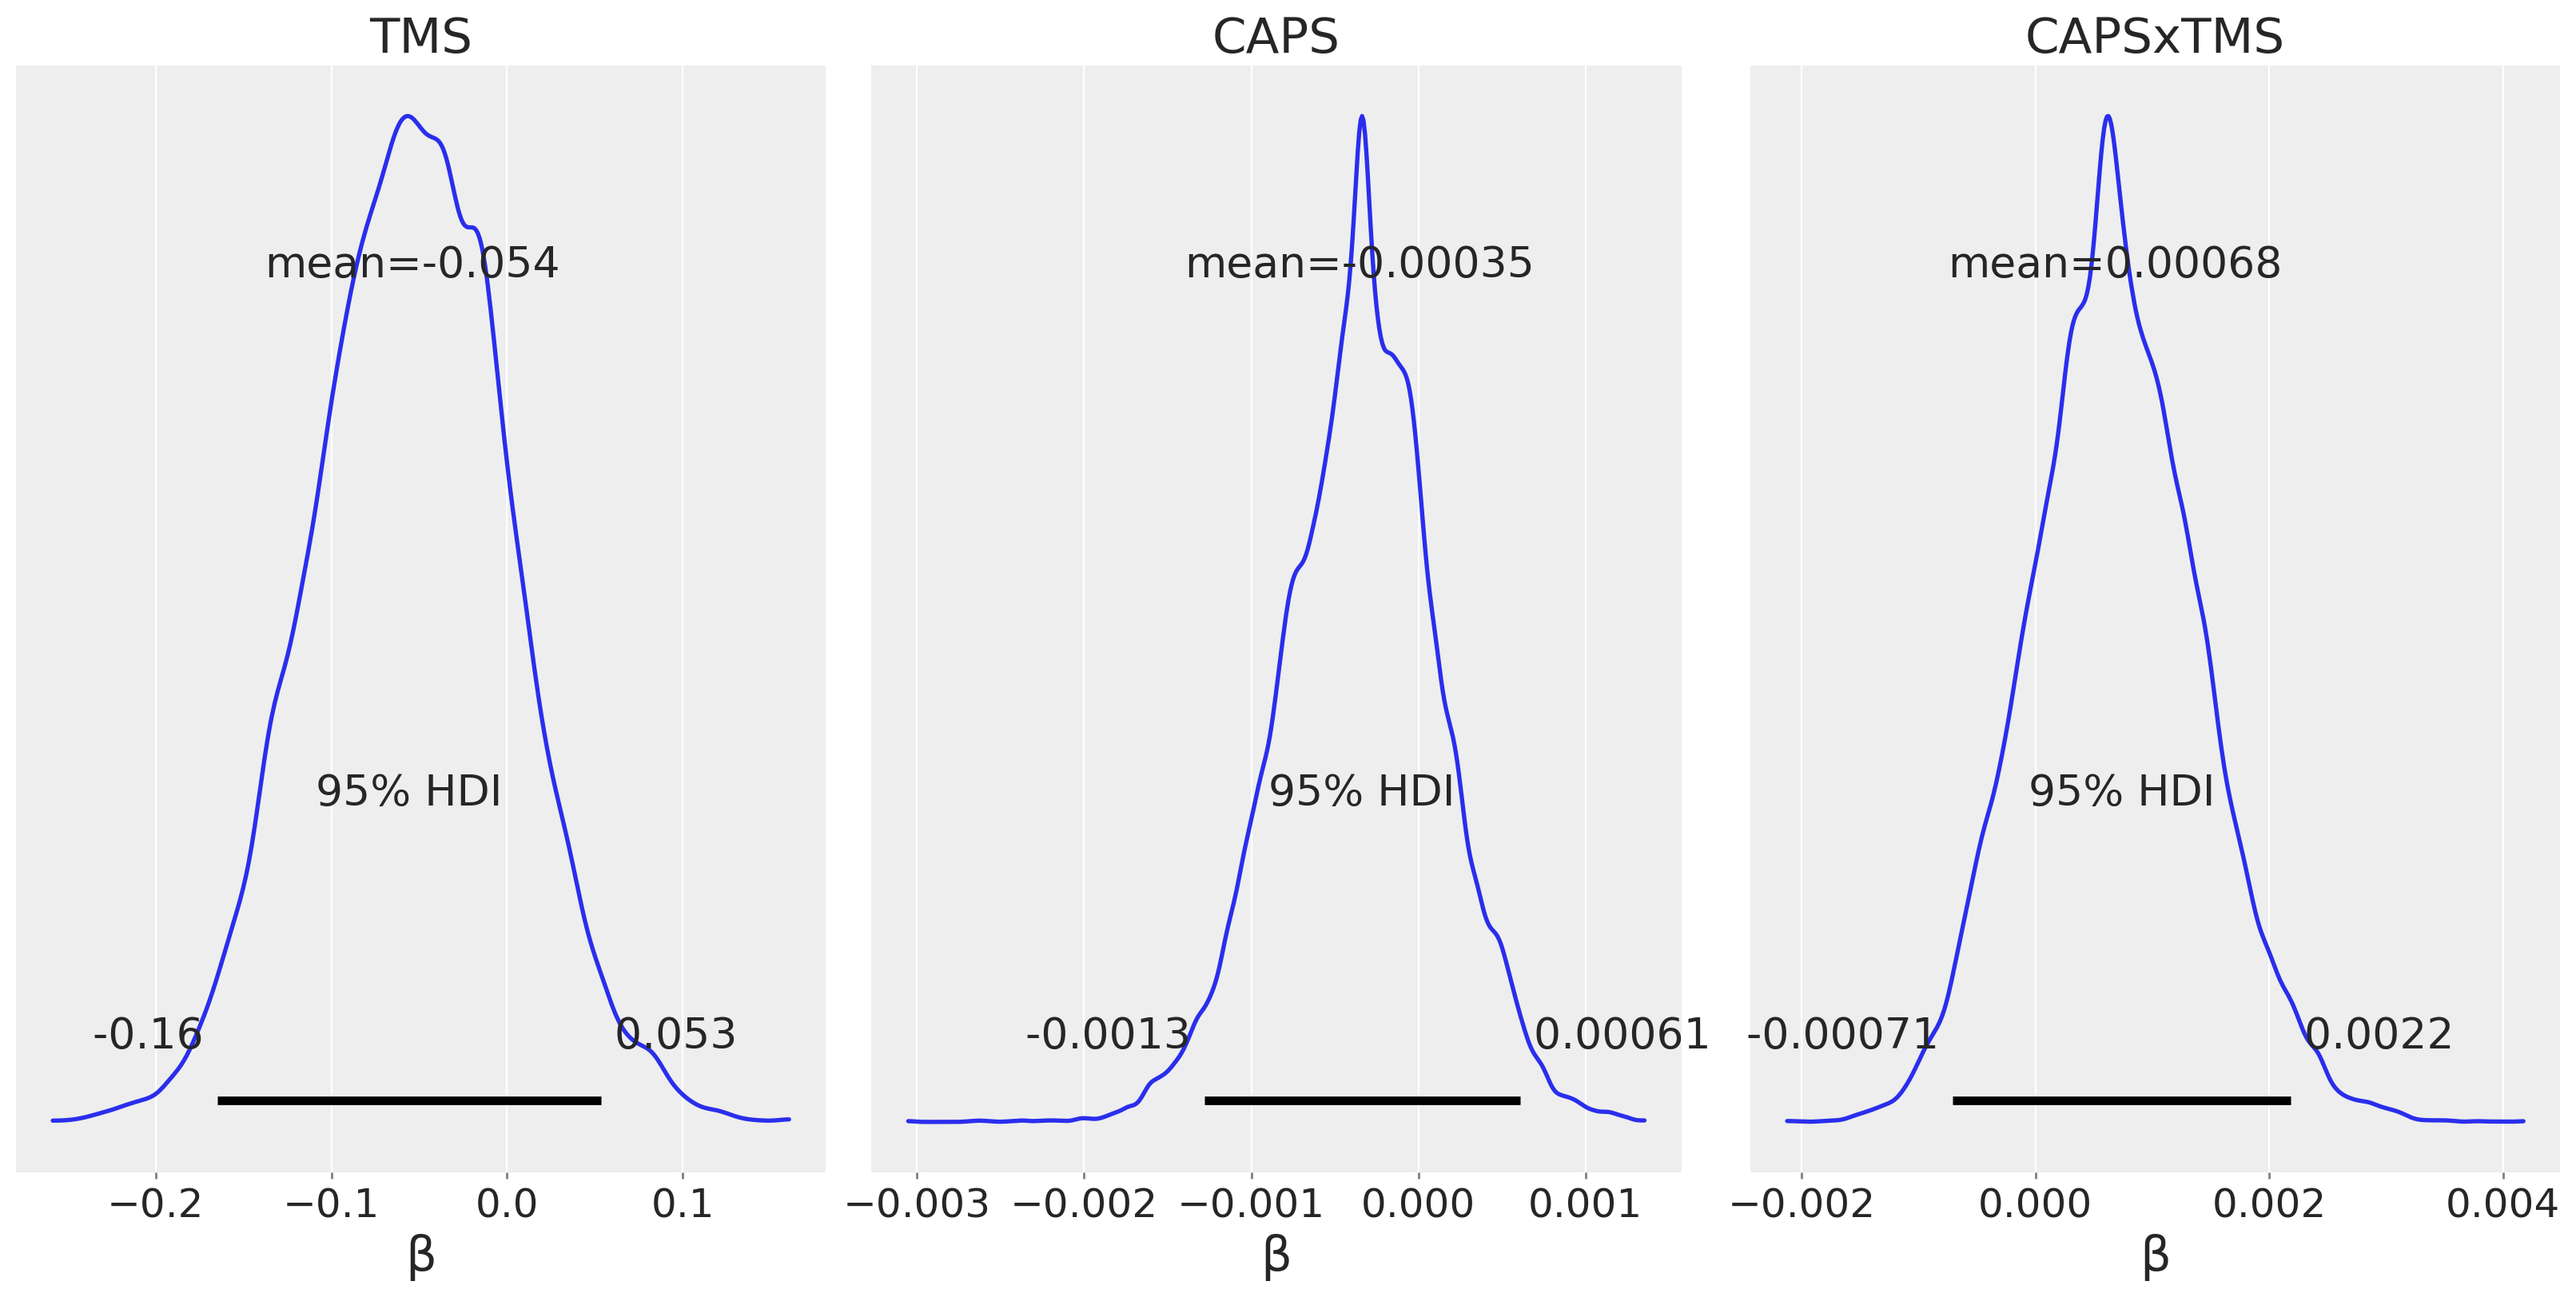

<Figure size 1600x800 with 0 Axes>

In [19]:
plot=az.plot_posterior(hr_conf_trace, var_names=["mu_beta_tms","mu_beta_caps", "mu_beta_tmsXcaps"],
                       textsize=18,
                       hdi_prob=0.95,
                       figsize={16, 8});                     

# Set the DPI for high resolution
dpi = 300
# Add the existing axes to the new Figure

# Get the axes from the plot
axes = plot.ravel()

# Create a new Figure and specify the spacing between subplots
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(3, 1, hspace=0.4)  # Customize hspace as needed

for i in range(3):
    ax = axes[i]
    ax.set_xlabel("β",fontsize=22)  # Set the custom y-axis label here

# Set the titles for each subplot
titles = ["TMS", "CAPS", "CAPSxTMS"]

# Loop through each subplot and set the title
for i, ax in enumerate(plot.ravel()):
    ax.set_title(titles[i],fontsize=22)
    
# Get the figure object
fig = plot.ravel()[0].figure
    
# Save the image with high resolution
fig.savefig("supl_study2_mu_bBT_capsxtms_traces.png", dpi=dpi)


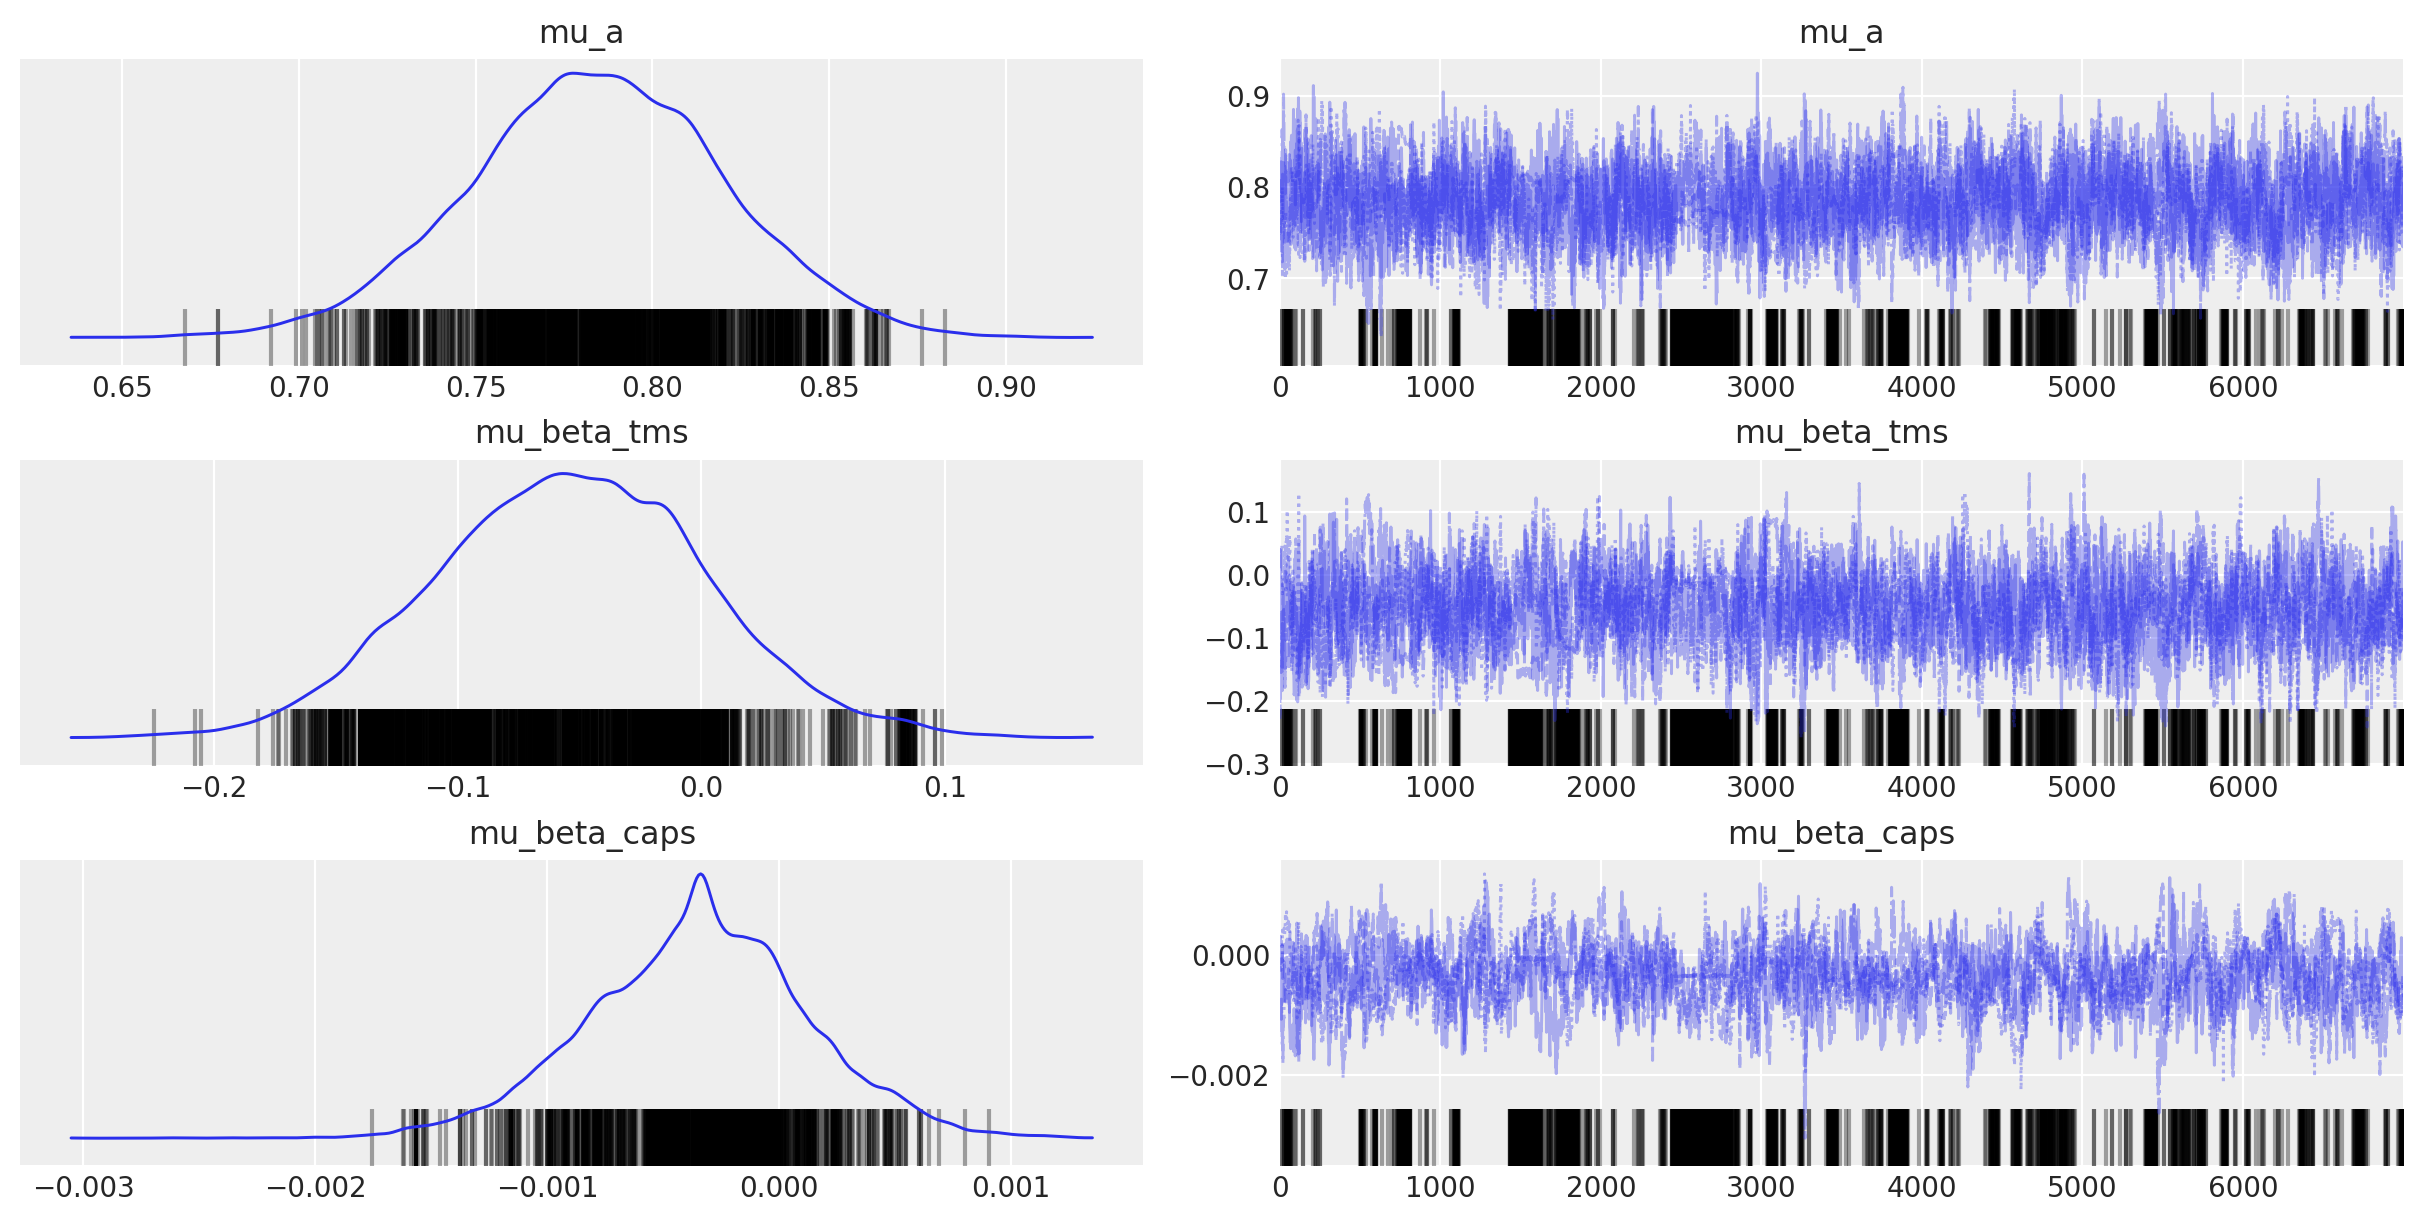

In [14]:
az.plot_trace(hr_conf_trace, var_names=["mu_a", "mu_beta_tms", "mu_beta_caps"],
             combined=True,
             coords={"participant": participant});


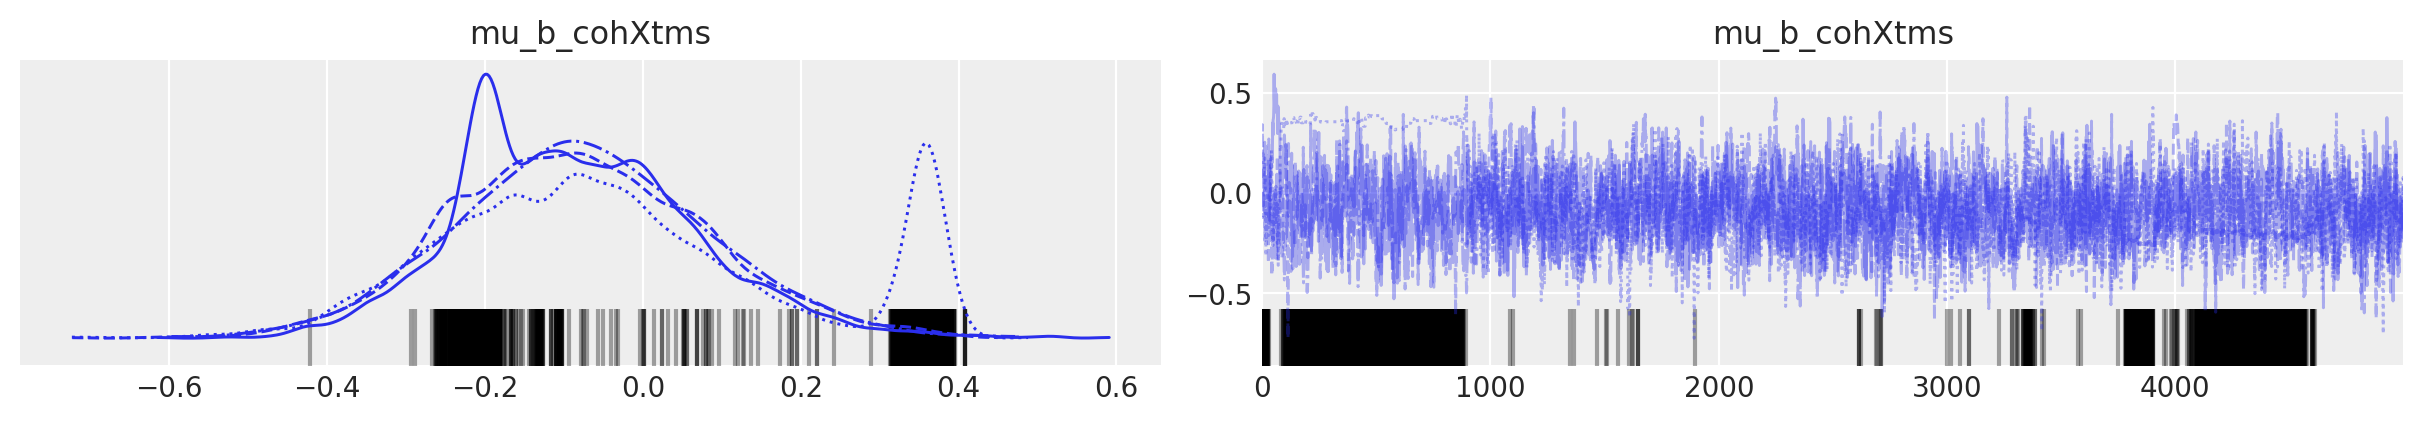

In [10]:
az.plot_trace(hr_conf_trace, var_names=["mu_beta_cohXtms"]);


ValueError: not enough values to unpack (expected 2, got 1)

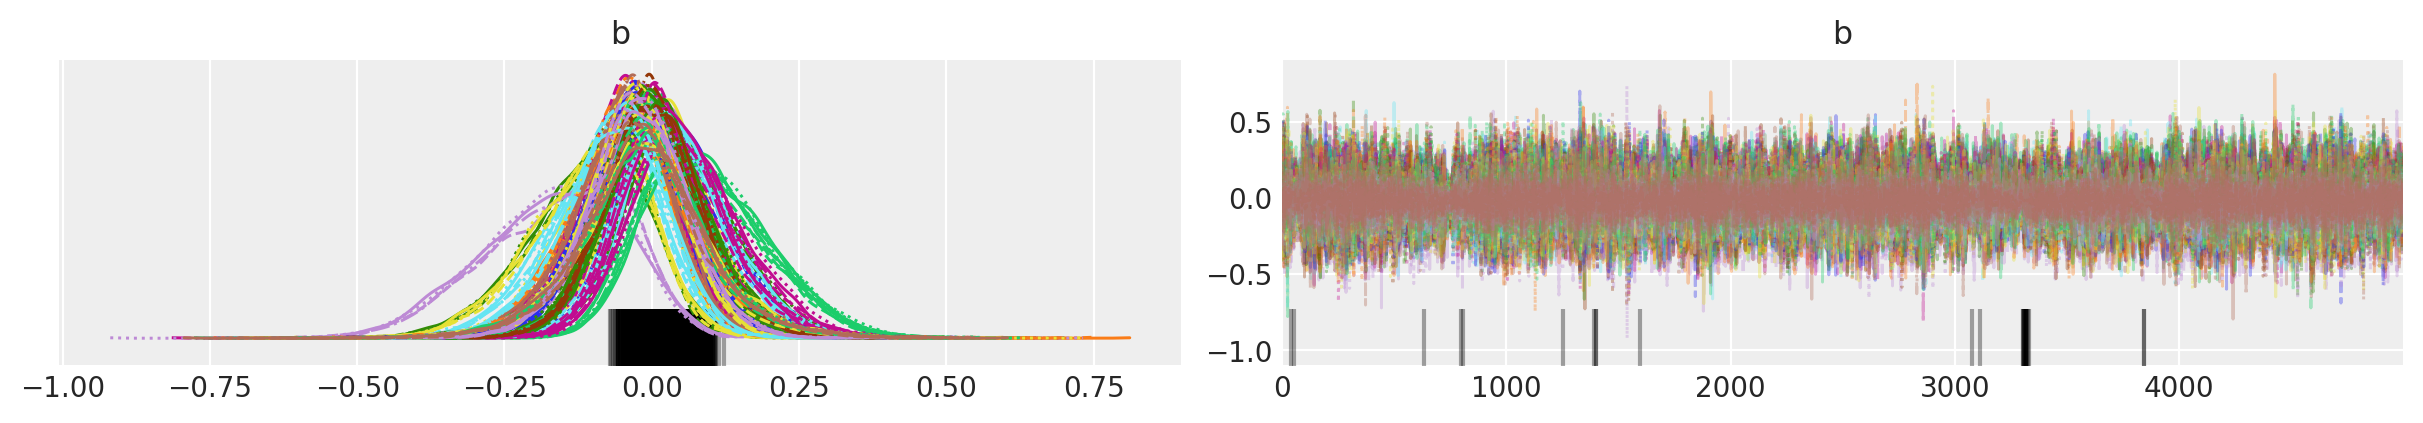

In [12]:
fig, b_trace_conf=az.plot_trace(hr_conf_trace, var_names=["b"], coords={"participant": participant});
b_trace_conf.save("b_trace_conf.jpg")

In [11]:
stat_tms_reg=pm.summary(hr_conf_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.614,0.025,0.566,0.662,0.000,0.000,3182.0,5822.0,1.01
mu_b,-0.012,0.039,-0.083,0.063,0.001,0.001,1999.0,2109.0,1.03
mu_b_coh,0.954,0.122,0.671,1.158,0.015,0.011,98.0,18.0,1.03
mu_b_cohXtms,-0.068,0.177,-0.342,0.361,0.021,0.015,110.0,18.0,1.03
a[0],0.565,0.084,0.401,0.720,0.002,0.001,2932.0,1616.0,1.01
...,...,...,...,...,...,...,...,...,...
sigma_a,0.142,0.018,0.108,0.172,0.001,0.001,439.0,4424.0,1.01
sigma_b,0.085,0.047,0.007,0.158,0.005,0.003,73.0,24.0,1.04
sigma_b_coh,0.423,0.097,0.233,0.596,0.005,0.004,324.0,1482.0,1.02
sigma_b_cohXtms,0.282,0.164,0.027,0.556,0.014,0.010,121.0,102.0,1.05


In [64]:
b_mu_reg=stat_tms_reg.loc['mu_beta']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_beta']['sd']

In [65]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.05))
print (b_tms)

OVL Beta TMS vs O
0.7957121648293113


In [66]:
conf_1=trace_groups.get_values(varname="mu", chains=1)
conf_1=pd.DataFrame(conf_1)

NameError: name 'trace_groups' is not defined

In [67]:
with hr_conf:
    ppc_reg = pm.sample_posterior_predictive(
        hr_conf_trace, var_names=["a", "b","confidence_BT_like"]
    )

<Axes: xlabel='confidence_like'>

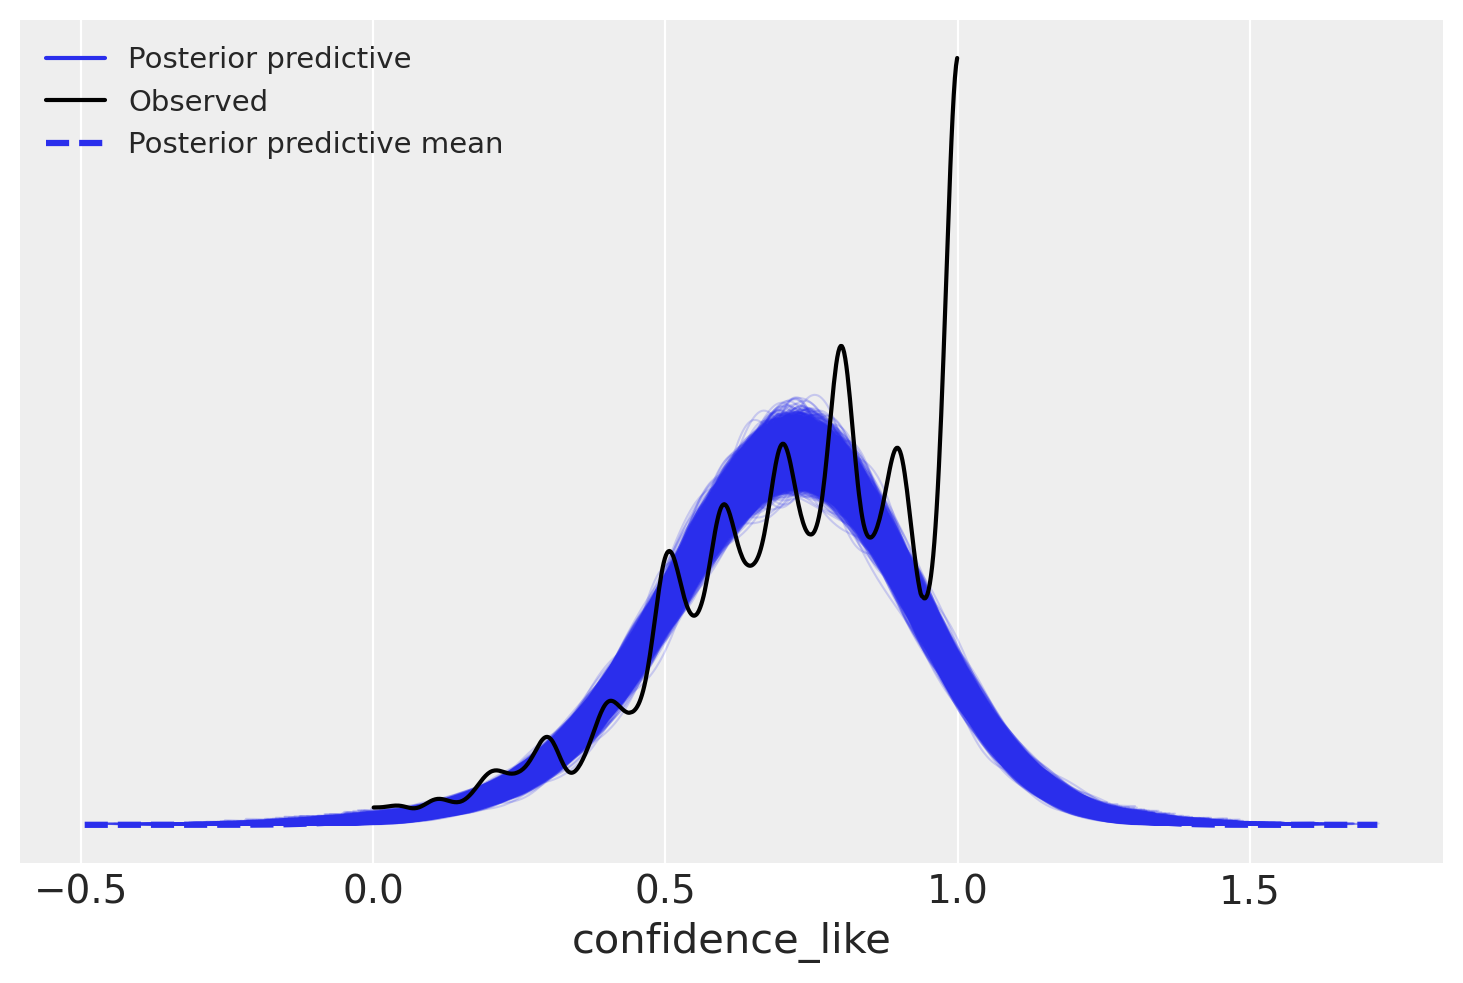

In [68]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_conf))